In [1]:
pip install kaggle

In [2]:
import os

# Set the KAGGLE_API_TOKEN environment variable
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_c6b135f80dc02dd34e548279be758cb0'

print("KAGGLE_API_TOKEN environment variable has been set. You can now use the `!kaggle` command to download datasets.")

KAGGLE_API_TOKEN environment variable has been set. You can now use the `!kaggle` command to download datasets.


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [4]:
import pandas as pd
import os

# Construct the full path to the 'IMDB Dataset.csv' file
file_path = os.path.join(path, 'IMDB Dataset.csv')

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nConcise summary of the DataFrame:")
df.info()

print("\nDistribution of unique values in the 'sentiment' column:")
print(df['sentiment'].value_counts())

First 5 rows of the DataFrame:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Concise summary of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Distribution of unique values in the 'sentiment' column:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


**Reasoning**:
To preprocess the text data and encode the sentiment labels as per the subtask instructions, I will define a cleaning function using regular expressions to remove HTML tags, punctuation, and special characters, then convert the text to lowercase. After applying this function to the 'review' column, I will encode the 'sentiment' column into numerical values (1 for positive, 0 for negative) and display the updated DataFrame.



In [5]:
import re

def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation and special characters, keep alphanumeric and spaces
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)
    # Convert to lowercase
    text = text.lower()
    return text

# Apply the clean_text function to the 'review' column
df['cleaned_review'] = df['review'].apply(clean_text)

# Map 'sentiment' to numerical values
df['sentiment_encoded'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("First 5 rows of the DataFrame with cleaned review and encoded sentiment:")
print(df[['review', 'cleaned_review', 'sentiment', 'sentiment_encoded']].head())

First 5 rows of the DataFrame with cleaned review and encoded sentiment:
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                      cleaned_review sentiment  \
0  one of the other reviewers has mentioned that ...  positive   
1  a wonderful little production the filming tech...  positive   
2  i thought this was a wonderful way to spend ti...  positive   
3  basically theres a family where a little boy j...  negative   
4  petter matteis love in the time of money is a ...  positive   

   sentiment_encoded  
0                  1  
1                  1  
2                  1  
3                  0  
4                  1  


## Generate Word Embeddings

### Subtask:
Convert the preprocessed text reviews into numerical word embeddings, preparing the data for the RNN model.


**Reasoning**:
To generate word embeddings, I will first import the necessary modules, then initialize and fit a Tokenizer on the cleaned review text, convert the text to sequences, and finally pad these sequences to a uniform length for use in an RNN model.



In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Initialize Tokenizer
tokenizer = Tokenizer(num_words=None, oov_token='<unk>')

tokenizer.fit_on_texts(df['cleaned_review'])

sequences = tokenizer.texts_to_sequences(df['cleaned_review'])

X = pad_sequences(sequences, maxlen=1500, padding='post')

max_length=1500
print(f"Maximum sequence length: {max_length}")
print(f"Shape of the padded sequences (X): {X.shape}")
print("First 5 padded sequences:")
print(X[:5])

Maximum sequence length: 1500
Shape of the padded sequences (X): (50000, 1500)
First 5 padded sequences:
[[   28     5     2 ...     0     0     0]
 [    4   383   114 ...     0     0     0]
 [   10   192    11 ...     0     0     0]
 [  684   222     4 ...     0     0     0]
 [83308 33897   110 ...     0     0     0]]


## Split Data

### Subtask:
Split the dataset into training and testing sets to prepare for model training and evaluation.


In [21]:
from sklearn.model_selection import train_test_split

y = df['sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (40000, 1500)
Shape of X_test: (10000, 1500)
Shape of y_train: (40000,)
Shape of y_test: (10000,)


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    MaxPooling1D,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)
# Get vocabulary size from tokenizer.word_index attribute (add 1 for the reserved 0 index)
vocab_size = len(tokenizer.word_index) + 1

# Define embedding dimensions
embedding_dim = 64  # You can experiment with this value
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Dropout(0.5),
    Conv1D(128, 5, activation='relu'),
    MaxPooling1D(4),
    Bidirectional(LSTM(64)),  # You can experiment with the number of LSTM units
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary
print("Model Summary:")
model.summary()

# Train the model
print("\nTraining the model...")
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

print("\nModel training complete.")

Model Summary:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 1500, 64)       │    14,201,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1500, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 1496, 128)      │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 374, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,341,569 (54.71 MB)

 Trainable params: 14,341,569 (54.71 MB)

 Non-trainable params: 0 (0.00 B)


Training the model...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 57ms/step - accuracy: 0.7070 - loss: 0.5133 - val_accuracy: 0.8990 - val_loss: 0.2610
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.9367 - loss: 0.1787 - val_accuracy: 0.9005 - val_loss: 0.2487
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.9677 - loss: 0.0962 - val_accuracy: 0.8933 - val_loss: 0.2793
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.9835 - loss: 0.0542 - val_accuracy: 0.8896 - val_loss: 0.3389
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.9888 - loss: 0.0379 - val_accuracy: 0.8903 - val_loss: 0.4370

Model training complete.


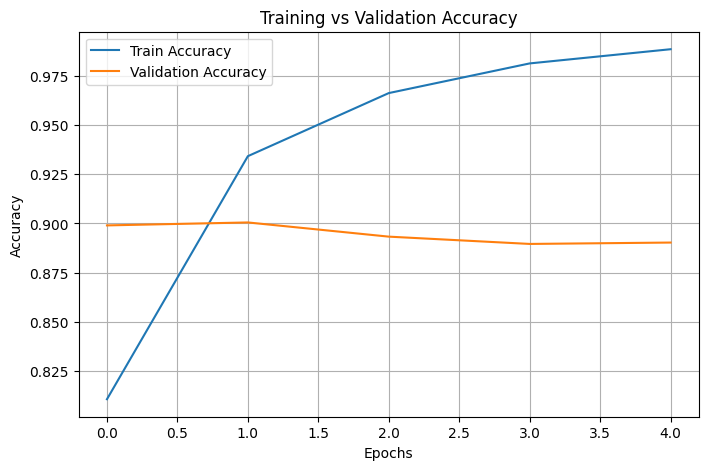

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


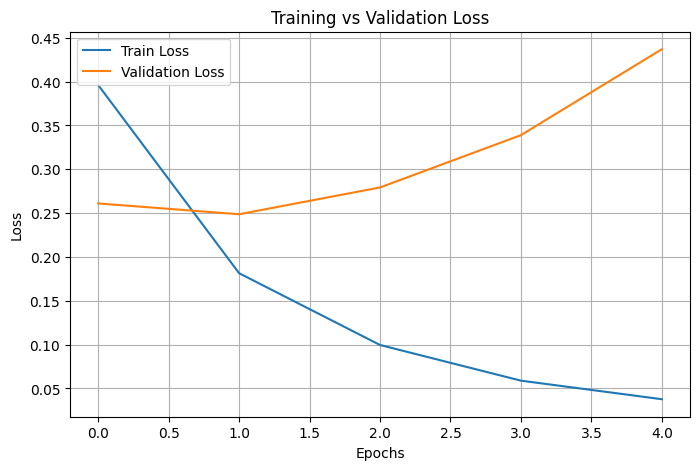

In [26]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


In [30]:
from sklearn.metrics import f1_score, balanced_accuracy_score

print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))


Balanced accuracy: 0.6092
Macro F1: 0.591775526178157


In [33]:
import os

os.makedirs("models", exist_ok=True)
model.save("models/ReviewSA_model.keras")
